# Week 4 – Univariate Analysis, part 2
## Dataset: SHED Public Use Data 2025
*Survey of Household Economics and Decisionmaking — Federal Reserve Board*

# 1. Lesson – None

# 2. Weekly Graph Question

Below are a histogram and boxplot of the same simulated pharmacy drug-price data. An administrator wants to understand how much the **more expensive drugs** tend to cost, in context.

75th percentile: 15.46


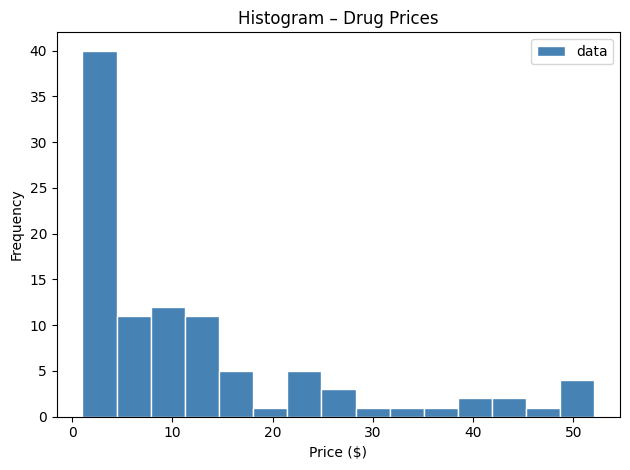

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size=num_data) * 4)
df_pharmacy = pd.DataFrame(data.T, columns=["data"])

print(f"75th percentile: {df_pharmacy.quantile(q=0.75).values[0]:.2f}")
df_pharmacy.plot.hist(title="Histogram – Drug Prices", xlabel="Price ($)", bins=15, color='steelblue', edgecolor='white')
plt.tight_layout()
plt.show()

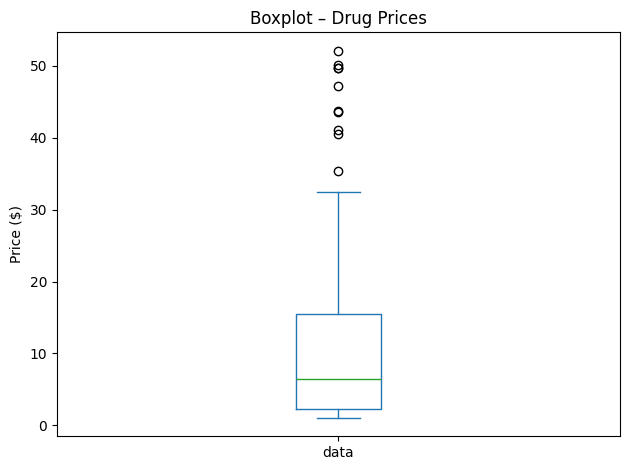

In [5]:
df_pharmacy.plot.box(title="Boxplot – Drug Prices", ylabel="Price ($)")
plt.tight_layout()
plt.show()

## Written Response: Histogram vs. Boxplot

**Pros and cons:**

| Feature | Histogram | Boxplot |
|---|---|---|
| Shows distribution shape | ✓ Yes – reveals skew, peaks, gaps | ✗ No shape detail |
| Shows outliers clearly | ✗ Buried in tail bins | ✓ Explicitly marks outliers |
| Shows exact percentiles | ✗ Approximate only | ✓ Q1, median, Q3, whiskers |
| Good for comparing groups | Possible but cluttered | ✓ Side-by-side is clean |
| Ease of reading for non-experts | ✓ Intuitive | ✗ Requires explanation |
| Best for large counts | ✓ Yes | ✓ Yes |

**For the pharmacy administrator asking about expensive drugs:**

I would choose the **boxplot**. The administrator's specific question is about the upper tail — *how much do expensive drugs cost relative to others?* The boxplot directly answers this: the upper whisker and individual outlier dots show precisely how far the high-cost drugs extend beyond the 75th percentile. A histogram shows the overall shape (heavily right-skewed, as expected for drug prices) but the tall stack of cheap drugs visually overwhelms the expensive ones in the right tail, making it harder to read their exact range.

**Formatting improvements I would make:**
- Add a reference line at the 75th percentile on the boxplot
- Label the outlier points with approximate values
- Use a log-scale x-axis on the histogram to reveal the full spread
- Add a title and axis labels with units ($)
- Remove the unnecessary y-axis label on the boxplot (only one series)

# 3. Homework – Working on Your Dataset

### **Dataset:** SHED Public Use Data 2025 — Survey of Household Economics and Decisionmaking, Federal Reserve Board.
### 


In [6]:

# Load dataset
shed = pd.read_csv("SHED_public_use_data_2025.csv",
                   low_memory=False)

print(f"Shape: {shed.shape}")
print(f"\nKey numeric stats:")
print(shed[['ppage', 'pphhsize', 'ppkid017']].describe())

Shape: (12908, 816)

Key numeric stats:
              ppage      pphhsize      ppkid017
count  12908.000000  12908.000000  12908.000000
mean      51.327394      2.675628      0.489929
std       18.167950      1.474739      0.976190
min       18.000000      1.000000      0.000000
25%       36.000000      2.000000      0.000000
50%       52.000000      2.000000      0.000000
75%       66.000000      3.000000      1.000000
max       98.000000     12.000000      9.000000


This dataset contains **12,908 survey respondents** and **816 columns** covering financial wellbeing, employment, income, education, housing, credit, and demographics across U.S. households. Key columns used:

| Column | Description |
|---|---|
| `ppage` | Respondent age |
| `pphhsize` | Household size |
| `ppkid017` | Number of children under 17 |
| `ppinc7` | Household income bracket |
| `ppreg4` | U.S. region |
| `ppgender` | Gender |
| `ppeducat` | Education level |
| `B2` | Self-reported financial wellbeing |
| `B3` | Financial situation compared to 12 months ago |

### 3a. Histograms for Numeric Features

We examine three core demographic/household numeric variables: **respondent age**, **household size**, and **number of children under 17**.

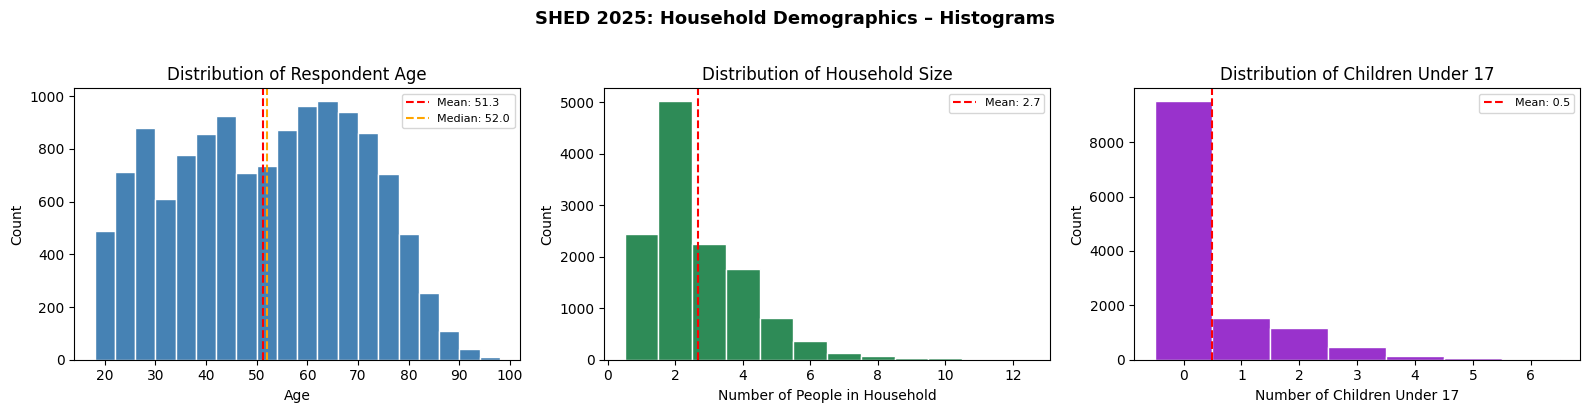

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Age histogram
axes[0].hist(shed['ppage'].dropna(), bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Respondent Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].axvline(shed['ppage'].mean(), color='red', linestyle='--', label=f"Mean: {shed['ppage'].mean():.1f}")
axes[0].axvline(shed['ppage'].median(), color='orange', linestyle='--', label=f"Median: {shed['ppage'].median():.1f}")
axes[0].legend(fontsize=8)

# Household size histogram
axes[1].hist(shed['pphhsize'].dropna(), bins=range(1, 14), color='seagreen', edgecolor='white', align='left')
axes[1].set_title('Distribution of Household Size')
axes[1].set_xlabel('Number of People in Household')
axes[1].set_ylabel('Count')
axes[1].axvline(shed['pphhsize'].mean(), color='red', linestyle='--', label=f"Mean: {shed['pphhsize'].mean():.1f}")
axes[1].legend(fontsize=8)

# Children under 17 histogram
axes[2].hist(shed['ppkid017'].dropna(), bins=range(0, 8), color='darkorchid', edgecolor='white', align='left')
axes[2].set_title('Distribution of Children Under 17')
axes[2].set_xlabel('Number of Children Under 17')
axes[2].set_ylabel('Count')
axes[2].axvline(shed['ppkid017'].mean(), color='red', linestyle='--', label=f"Mean: {shed['ppkid017'].mean():.1f}")
axes[2].legend(fontsize=8)

plt.suptitle('SHED 2025: Household Demographics – Histograms', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3b. KDE Plot and Violin Plot

A **KDE (Kernel Density Estimate)** plot smooths the histogram into a continuous curve, making it easier to see the shape of the distribution. A **violin plot** combines a KDE with a boxplot.

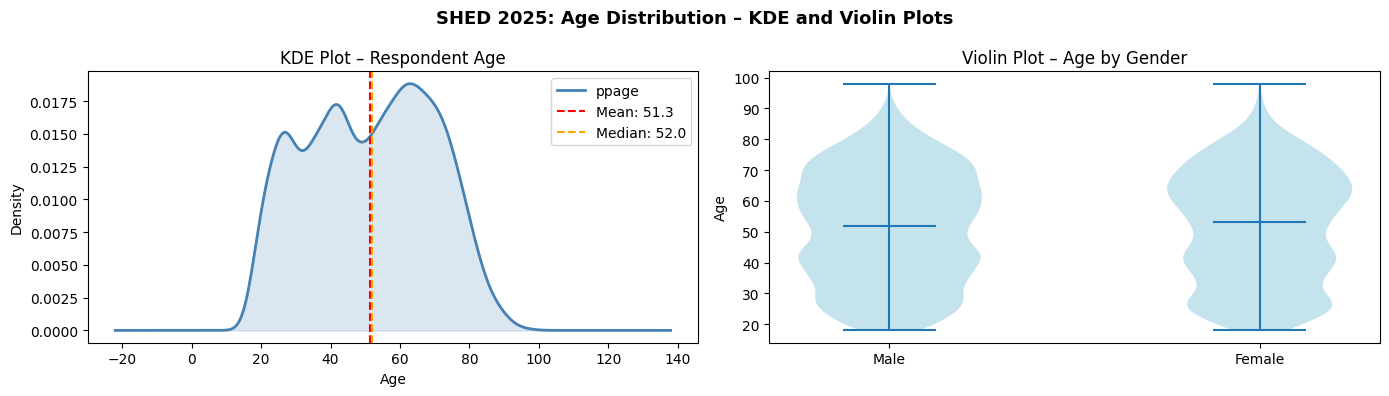

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# KDE plot of age
shed['ppage'].dropna().plot.kde(ax=axes[0], color='steelblue', lw=2)
axes[0].fill_between(axes[0].lines[0].get_xdata(), axes[0].lines[0].get_ydata(), alpha=0.2, color='steelblue')
axes[0].set_title('KDE Plot – Respondent Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Density')
axes[0].axvline(shed['ppage'].mean(), color='red', linestyle='--', label=f"Mean: {shed['ppage'].mean():.1f}")
axes[0].axvline(shed['ppage'].median(), color='orange', linestyle='--', label=f"Median: {shed['ppage'].median():.1f}")
axes[0].legend()

# Violin plot of age by gender
import matplotlib.patches as mpatches
gender_groups = [shed[shed['ppgender'] == g]['ppage'].dropna().values for g in ['Male', 'Female']]
parts = axes[1].violinplot(gender_groups, positions=[1, 2], showmedians=True, showextrema=True)
for pc in parts['bodies']:
    pc.set_facecolor('lightblue')
    pc.set_alpha(0.7)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['Male', 'Female'])
axes[1].set_title('Violin Plot – Age by Gender')
axes[1].set_ylabel('Age')

plt.suptitle('SHED 2025: Age Distribution – KDE and Violin Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3c. Grouped Histograms

We compare the **age distribution** across four financial wellbeing categories (`B2`). This reveals whether financial comfort levels differ by demographic cohort.

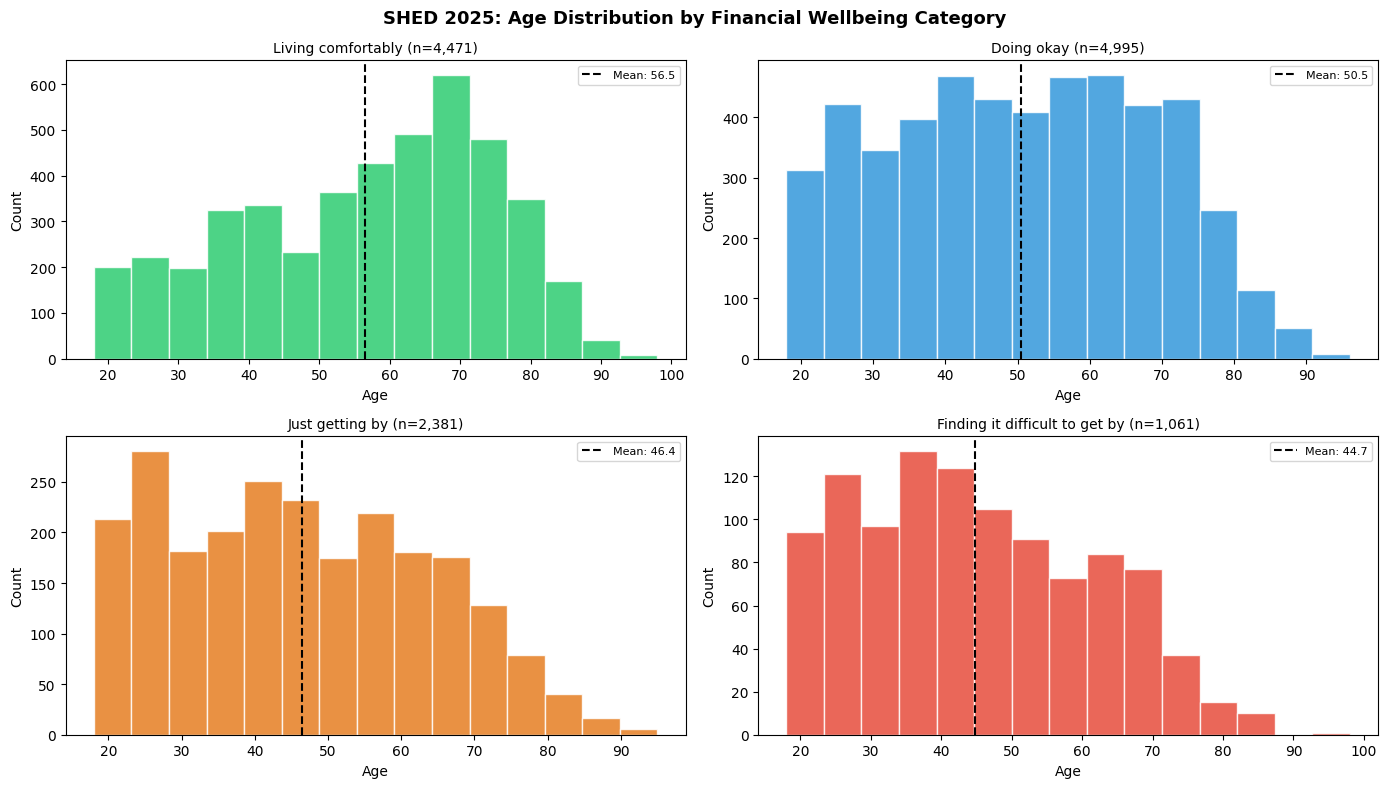

In [9]:
wellbeing_order = ['Living comfortably', 'Doing okay', 'Just getting by', 'Finding it difficult to get by']
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, (cat, color) in enumerate(zip(wellbeing_order, colors)):
    subset = shed[shed['B2'] == cat]['ppage'].dropna()
    axes[i].hist(subset, bins=15, color=color, edgecolor='white', alpha=0.85)
    axes[i].axvline(subset.mean(), color='black', linestyle='--', lw=1.5, label=f'Mean: {subset.mean():.1f}')
    axes[i].set_title(f'{cat} (n={len(subset):,})', fontsize=10)
    axes[i].set_xlabel('Age')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

plt.suptitle('SHED 2025: Age Distribution by Financial Wellbeing Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3d. Bar Plots for Categorical Variables

Counting the frequency of each category reveals how the survey sample is distributed across income, education, region, and financial wellbeing.

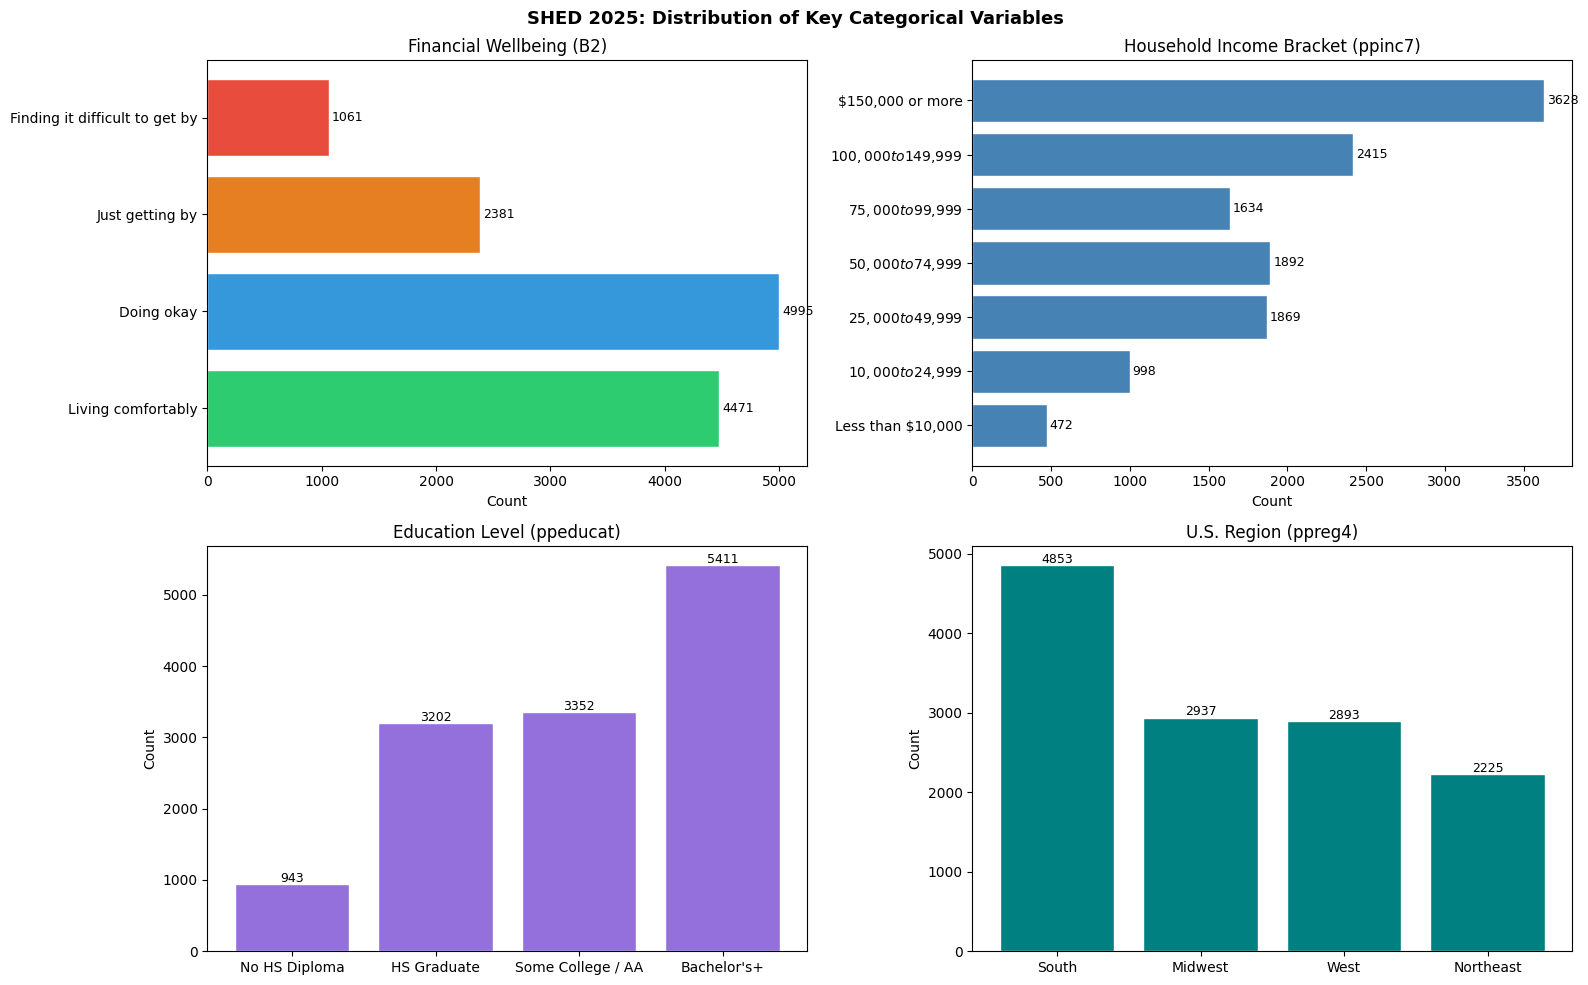

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Financial wellbeing
wellbeing_counts = shed['B2'].value_counts().reindex(wellbeing_order)
axes[0, 0].barh(wellbeing_counts.index, wellbeing_counts.values,
                color=['#2ecc71', '#3498db', '#e67e22', '#e74c3c'], edgecolor='white')
axes[0, 0].set_title('Financial Wellbeing (B2)')
axes[0, 0].set_xlabel('Count')
for i, v in enumerate(wellbeing_counts.values):
    axes[0, 0].text(v + 30, i, str(v), va='center', fontsize=9)

# Income bracket
income_order = ['Less than $10,000', '$10,000 to $24,999', '$25,000 to $49,999',
                '$50,000 to $74,999', '$75,000 to $99,999', '$100,000 to $149,999', '$150,000 or more']
income_counts = shed['ppinc7'].value_counts().reindex(income_order)
axes[0, 1].barh(income_counts.index, income_counts.values, color='steelblue', edgecolor='white')
axes[0, 1].set_title('Household Income Bracket (ppinc7)')
axes[0, 1].set_xlabel('Count')
for i, v in enumerate(income_counts.values):
    axes[0, 1].text(v + 20, i, str(v), va='center', fontsize=9)

# Education
edu_order = ['No high school diploma or GED',
             'High school graduate (high school diploma or the equivalent GED)',
             'Some college or Associate\'s degree',
             'Bachelor\'s degree or higher']
edu_labels = ['No HS Diploma', 'HS Graduate', 'Some College / AA', "Bachelor's+"]
edu_counts = shed['ppeducat'].value_counts().reindex(edu_order)
axes[1, 0].bar(edu_labels, edu_counts.values, color='mediumpurple', edgecolor='white')
axes[1, 0].set_title('Education Level (ppeducat)')
axes[1, 0].set_ylabel('Count')
for i, v in enumerate(edu_counts.values):
    axes[1, 0].text(i, v + 30, str(v), ha='center', fontsize=9)

# Region
region_counts = shed['ppreg4'].value_counts()
axes[1, 1].bar(region_counts.index, region_counts.values, color='teal', edgecolor='white')
axes[1, 1].set_title('U.S. Region (ppreg4)')
axes[1, 1].set_ylabel('Count')
for i, v in enumerate(region_counts.values):
    axes[1, 1].text(i, v + 30, str(v), ha='center', fontsize=9)

plt.suptitle('SHED 2025: Distribution of Key Categorical Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3e. Means, Medians, and Modes

Descriptive statistics for the key numeric features.

In [11]:
from scipy import stats

numeric_cols = ['ppage', 'pphhsize', 'ppkid017']
col_labels = ['Respondent Age', 'Household Size', 'Children Under 17']

print("-" * 55)
print(f"{'Statistic':<22} {'Age':>10} {'HH Size':>10} {'Kids<17':>10}")
print("-" * 55)
for stat_name, func in [("Mean", np.mean), ("Median", np.median)]:
    vals = [func(shed[c].dropna()) for c in numeric_cols]
    print(f"{stat_name:<22} {vals[0]:>10.2f} {vals[1]:>10.2f} {vals[2]:>10.2f}")
# Mode
modes = [shed[c].mode()[0] for c in numeric_cols]
print(f"{'Mode':<22} {modes[0]:>10.0f} {modes[1]:>10.0f} {modes[2]:>10.0f}")
# Std
stds = [shed[c].std() for c in numeric_cols]
print(f"{'Std Dev':<22} {stds[0]:>10.2f} {stds[1]:>10.2f} {stds[2]:>10.2f}")
print("-" * 55)

# B2 mode
print(f"\nMode of Financial Wellbeing (B2): '{shed['B2'].mode()[0]}'")
print(f"Mode of Income Bracket (ppinc7): '{shed['ppinc7'].mode()[0]}'")
print(f"Mode of Education (ppeducat): '{shed['ppeducat'].mode()[0]}'")
print(f"Mode of Region (ppreg4): '{shed['ppreg4'].mode()[0]}'")

-------------------------------------------------------
Statistic                     Age    HH Size    Kids<17
-------------------------------------------------------
Mean                        51.33       2.68       0.49
Median                      52.00       2.00       0.00
Mode                           59          2          0
Std Dev                     18.17       1.47       0.98
-------------------------------------------------------

Mode of Financial Wellbeing (B2): 'Doing okay'
Mode of Income Bracket (ppinc7): '$150,000 or more'
Mode of Education (ppeducat): 'Bachelor's degree or higher'
Mode of Region (ppreg4): 'South'


### Conclusions

**Are the data what we expect? Are they usable?**
Yes. The SHED dataset is published by the Federal Reserve Board and is designed for public research. Variable coding and documentation are thorough.

**Distribution shapes:**
- **Age** is approximately uniform with a slight decrease at older ages, as survey participation declines with age. Mean ~51, median ~52 — nearly symmetric but with a slight left skew at the extremes.
- **Household size** is right-skewed: most households have 1–3 people, with few large households. Mode = 2.
- **Children under 17** is heavily right-skewed (zero-inflated): most respondents have no children.

**Outliers:**
- Age has no meaningful outliers (18–98, reasonable for a household survey).
- Household size has a small number of households with 8+ people, visible as a long tail.

**Grouped histograms insight:**
- Younger respondents cluster more often in the “Finding it difficult” and “Just getting by” groups, while older respondents (50+) dominate the “Living comfortably” group — consistent with expectations that wealth accumulates with age.

**Categorical distributions:**
- The sample skews toward higher income and education (over-representation of Bachelor’s+ and $150K+ income), which is typical for online surveys. Weights are provided for population-representative estimates.
- The South has the most respondents, reflecting U.S. population geography.

**Bin width effects:**
- For age with bins=20, the distribution looks roughly uniform. With bins=5, the shape flattens further. Bins=40 reveal slight oscillation around every 5-year increment (people tend to report round ages). For household size, single-unit bins (1 per category) are appropriate since values are discrete integers.

**Overall Assessment:** The SHED data is usable for classification and analysis of financial behavior. It requires careful interpretation since most columns are coded survey responses, not truly continuous measurements. The data is well-structured with predictable value ranges.

# 4. Storytelling With Data Graph

Reproduce a graph from pp. 52–68 of *Storytelling With Data* (Ch. 2 — Choosing an Effective Visual).

**Choice:** I am reproducing the style of a clean **horizontal bar chart** (p. 66–68), which the book presents as a go-to visual for comparing categories. The chart uses:
- Minimal ink / no unnecessary gridlines
- Direct data labels on bars
- A single highlighted color to draw attention to the most important bar
- A clear, specific title that states the insight

**Data:** Percentage of SHED respondents who report being *“Living comfortably”* or *“Doing okay”* (i.e., financially satisfied), grouped by household income bracket.

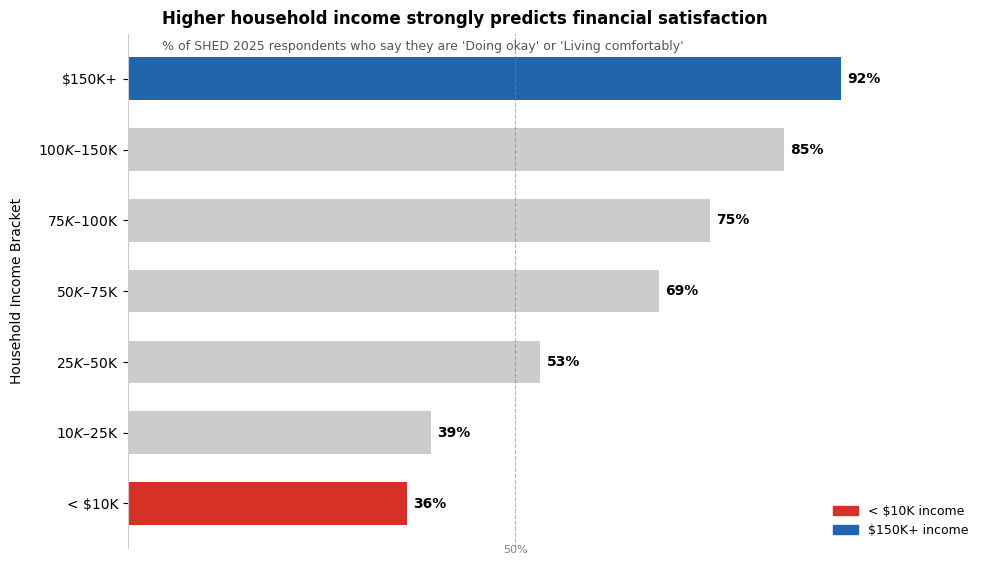

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# Compute % financially satisfied per income bracket
income_order = ['Less than $10,000', '$10,000 to $24,999', '$25,000 to $49,999',
                '$50,000 to $74,999', '$75,000 to $99,999',
                '$100,000 to $149,999', '$150,000 or more']
income_labels = ['< $10K', '$10K–$25K', '$25K–$50K', '$50K–$75K',
                 '$75K–$100K', '$100K–$150K', '$150K+']

results = []
for bracket in income_order:
    sub = shed[shed['ppinc7'] == bracket]['B2']
    if len(sub) > 0:
        pct = 100 * sub.isin(['Living comfortably', 'Doing okay']).sum() / len(sub)
        results.append(pct)
    else:
        results.append(0)

# ---- Storytelling With Data style chart ----
fig, ax = plt.subplots(figsize=(10, 5.5))

# Use a neutral grey for all bars, highlight the middle (transition point)
colors = ['#cccccc'] * 7
colors[-1] = '#2166ac'   # highlight highest income in blue
colors[0] = '#d73027'    # highlight lowest income in red

bars = ax.barh(income_labels, results, color=colors, height=0.6)

# Add data labels
for bar, val in zip(bars, results):
    ax.text(val + 0.8, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}%', va='center', ha='left', fontsize=10, fontweight='bold')

# Remove chart junk
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.xaxis.set_visible(False)
ax.set_xlim(0, 110)

# Add a vertical reference line at 50%
ax.axvline(50, color='grey', linestyle='--', lw=0.8, alpha=0.6)
ax.text(50, -0.7, '50%', ha='center', color='grey', fontsize=8)

# Title and subtitle (Storytelling With Data style: title = the insight)
fig.text(0.04, 1.02, 'Higher household income strongly predicts financial satisfaction',
         fontsize=12, fontweight='bold', transform=ax.transAxes)
fig.text(0.04, 0.97, '% of SHED 2025 respondents who say they are \'Doing okay\' or \'Living comfortably\'',
         fontsize=9, color='#555555', transform=ax.transAxes)

# Legend patches
patch_blue = mpatches.Patch(color='#2166ac', label='$150K+ income')
patch_red  = mpatches.Patch(color='#d73027', label='< $10K income')
ax.legend(handles=[patch_red, patch_blue], loc='lower right', frameon=False, fontsize=9)

ax.set_ylabel('Household Income Bracket', labelpad=10)
plt.tight_layout()
plt.show()